# Portfolio Risk Engine

## Correlated Multi-Asset Simulation, VaR, Expected Shortfall, and Stress Testing

This notebook builds on Week 1's GBM foundation and Week 2's derivatives
engine, adding the multi-asset dimension: correlated simulation, VaR/ES,
and scenario-based stress testing.

> **Central question:** given a portfolio of correlated assets, how much
> could I lose, and how does that answer change under a market shock?

Everything here is layered on existing APIs (`simulate_gbm`'s exact GBM
formula reused per-asset, `AssetParameters`/`PortfolioParameters` following
the validated-dataclass pattern of `MarketParameters`/`OptionParameters`) —
nothing in Week 1/2 was modified.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from app.models.portfolio_parameters import AssetParameters, PortfolioParameters

from app.quant.portfolio.correlated_gbm import (
    simulate_correlated_terminal_prices, realized_correlation,
)
from app.quant.portfolio.portfolio_simulation import simulate_portfolio
from app.quant.portfolio.risk_metrics import (
    historical_var, historical_expected_shortfall, historical_risk_metrics,
    parametric_var, parametric_expected_shortfall, parametric_risk_metrics,
)
from app.quant.portfolio.stress_testing import Scenario, run_stress_test, STANDARD_SCENARIOS
from app.quant.portfolio.reporting import generate_portfolio_risk_report

from app.visualization.portfolio import (
    plot_pnl_distribution, plot_correlation_heatmap,
    plot_var_by_confidence, plot_stress_comparison,
)

SEED = 42
np.set_printoptions(suppress=True, precision=4)

## 1. Portfolio Definition

A 4-asset equity portfolio, roughly diversified across sectors with
realistic drift/volatility assumptions. `PortfolioParameters` validates
weight/asset alignment and that the correlation matrix is symmetric,
unit-diagonal, bounded in [-1, 1], and positive semi-definite — the last
check matters because a non-PSD "correlation" matrix cannot be
Cholesky-decomposed, which is how correlation gets *induced* between
independently-drawn standard normals below.

In [2]:
assets = [
    AssetParameters(name="TechCo",   initial_price=180, drift=0.12, volatility=0.32),
    AssetParameters(name="BankCorp", initial_price=95,  drift=0.07, volatility=0.24),
    AssetParameters(name="EnergyX",  initial_price=60,  drift=0.06, volatility=0.28),
    AssetParameters(name="ConsumerY",initial_price=140, drift=0.08, volatility=0.18),
]
weights = [0.35, 0.25, 0.20, 0.20]

correlation_matrix = np.array([
    [1.00, 0.35, 0.20, 0.40],
    [0.35, 1.00, 0.25, 0.30],
    [0.20, 0.25, 1.00, 0.15],
    [0.40, 0.30, 0.15, 1.00],
])

portfolio = PortfolioParameters(
    assets=assets, weights=weights, correlation_matrix=correlation_matrix,
    portfolio_value=10_000_000, time_horizon=1.0,
)

for name, w, alloc in zip(portfolio.asset_names, portfolio.weights, portfolio.dollar_allocations):
    print(f"{name:<10} weight {w:>6.1%}   ${alloc:>12,.0f}")

TechCo     weight  35.0%   $   3,500,000
BankCorp   weight  25.0%   $   2,500,000
EnergyX    weight  20.0%   $   2,000,000
ConsumerY  weight  20.0%   $   2,000,000


## 2. Correlated Multi-Asset GBM

Each asset still follows its own exact GBM terminal-price formula from
Week 1. What's new is that the standard normal draws feeding each asset
are correlated via a Cholesky factor of the correlation matrix
(`Sigma = L L^T`, `Z_corr = Z @ L^T`) *before* being plugged into each
asset's independent GBM formula — so every asset's own marginal
distribution is untouched, only the co-movement between assets changes.

In [3]:
result = simulate_correlated_terminal_prices(portfolio, simulations=500_000, seed=SEED)

realized = realized_correlation(result.terminal_prices)
print("Target correlation:\n", correlation_matrix)
print("\nRealized correlation (500k sims):\n", realized)
print("\nMax abs deviation:", np.max(np.abs(realized - correlation_matrix)))

Target correlation:
 [[1.   0.35 0.2  0.4 ]
 [0.35 1.   0.25 0.3 ]
 [0.2  0.25 1.   0.15]
 [0.4  0.3  0.15 1.  ]]

Realized correlation (500k sims):
 [[1.     0.3495 0.2032 0.3987]
 [0.3495 1.     0.2523 0.2995]
 [0.2032 0.2523 1.     0.1512]
 [0.3987 0.2995 0.1512 1.    ]]

Max abs deviation: 0.003158006651594214


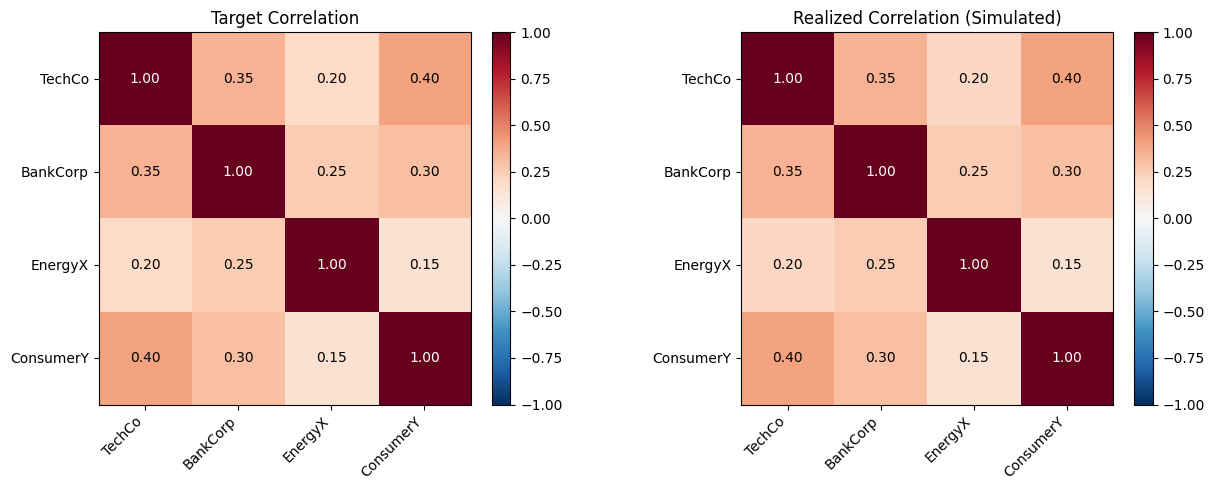

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_correlation_heatmap(correlation_matrix, portfolio.asset_names, ax=axes[0], title="Target Correlation")
plot_correlation_heatmap(realized, portfolio.asset_names, ax=axes[1], title="Realized Correlation (Simulated)")
plt.tight_layout()
plt.show()

## 3. Portfolio Value and P&L Simulation

`simulate_portfolio` converts each asset's simulated `S_T` into
portfolio-level value: today's dollar allocation is turned into a fixed
share count at `t=0`, then revalued at each simulated terminal price — a
static buy-and-hold portfolio over the horizon.

In [5]:
sim = simulate_portfolio(portfolio, simulations=500_000, seed=SEED)

print(f"Initial Value:      ${sim.initial_value:,.2f}")
print(f"Expected Terminal:  ${np.mean(sim.terminal_value):,.2f}")
print(f"Expected P&L:       ${np.mean(sim.pnl):,.2f}  ({np.mean(sim.pnl_pct):+.2%})")
print(f"P&L Std Dev:        ${np.std(sim.pnl, ddof=1):,.2f}")
print(f"Worst simulated P&L: ${np.min(sim.pnl):,.2f}")
print(f"Best simulated P&L:  ${np.max(sim.pnl):,.2f}")

Initial Value:      $10,000,000.00
Expected Terminal:  $10,919,598.77
Expected P&L:       $919,598.77  (+9.20%)
P&L Std Dev:        $2,081,308.43
Worst simulated P&L: $-5,296,529.21
Best simulated P&L:  $18,800,440.13


## 4. Value at Risk (VaR) and Expected Shortfall (ES)

Two independent methods, the same "Monte Carlo vs. closed-form
benchmark" pattern as Week 2's MC-vs-Black-Scholes:

- **Historical (simulation-based):** read percentiles/tail means
  directly off the simulated P&L — no distributional assumption beyond
  GBM itself.
- **Parametric (variance-covariance):** closed-form Normal formulas,
  included as an analytical cross-check. Expected to diverge somewhat
  since simulated portfolio P&L (a sum of log-normal terms) is not
  exactly Normal.

Both are reported as **positive loss numbers** (standard risk-reporting
convention).

In [6]:
hist95 = historical_risk_metrics(sim.pnl, 0.95)
param95 = parametric_risk_metrics(sim.pnl, 0.95)

print(hist95)
print()
print(param95)
print()
print(f"VaR difference (historical - parametric): ${hist95.var - param95.var:,.2f}")

95% VaR (historical):  $2,088,116.42
95% ES  (historical):  $2,643,556.60

95% VaR (parametric):  $2,503,848.94
95% ES  (parametric):  $3,373,542.78

VaR difference (historical - parametric): $-415,732.52


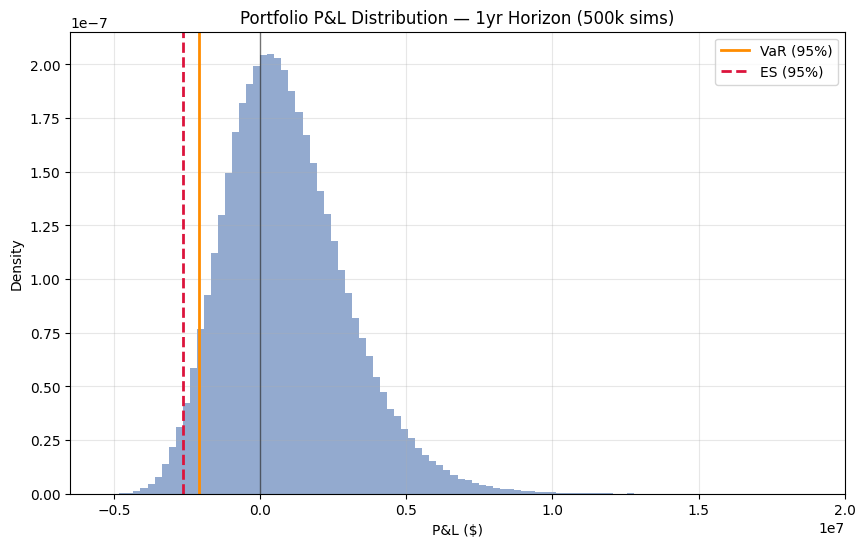

In [7]:
plot_pnl_distribution(sim.pnl, hist95, title="Portfolio P&L Distribution — 1yr Horizon (500k sims)")
plt.show()

### VaR/ES across confidence levels

Both risk figures should increase monotonically with confidence level —
a 99% VaR must exceed a 90% VaR, since it's a stricter loss threshold
exceeded less often.

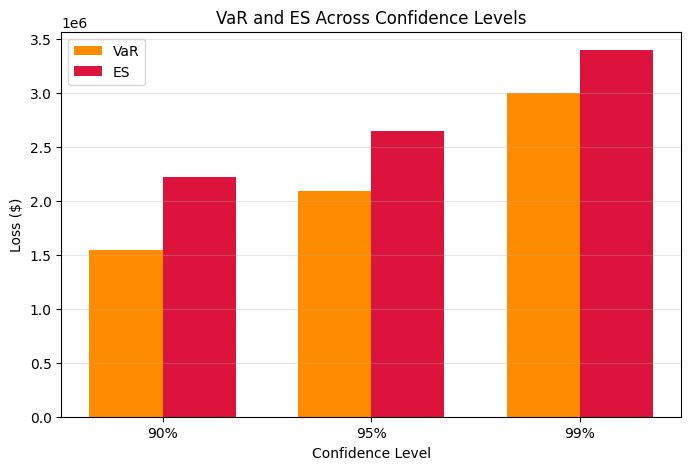

90%:  VaR $1,545,466.52   ES $2,220,512.23
95%:  VaR $2,088,116.42   ES $2,643,556.60
99%:  VaR $3,000,555.59   ES $3,396,483.82


In [8]:
plot_var_by_confidence(sim.pnl, confidence_levels=(0.90, 0.95, 0.99))
plt.show()

for level in (0.90, 0.95, 0.99):
    r = historical_risk_metrics(sim.pnl, level)
    print(f"{level:.0%}:  VaR ${r.var:>12,.2f}   ES ${r.expected_shortfall:>12,.2f}")

### Full risk report

`generate_portfolio_risk_report` bundles simulation + both VaR/ES
methods into one call and a formatted dashboard, mirroring
`generate_paired_pricing_report` from Week 2.

In [9]:
report = generate_portfolio_risk_report(portfolio, simulations=200_000, confidence_level=0.95, seed=SEED)
print(report)

Portfolio Risk Report
──────────────────────

Holdings
  TechCo       weight  35.00%   $  3,500,000.00
  BankCorp     weight  25.00%   $  2,500,000.00
  EnergyX      weight  20.00%   $  2,000,000.00
  ConsumerY    weight  20.00%   $  2,000,000.00

Portfolio Value (t=0):   $10,000,000.00
Horizon:                  1.00 yr
Simulations:              200,000

Expected Terminal Value: $10,915,848.54
Expected P&L:            $915,848.54 (+9.16%)
P&L Std Dev:             $2,083,370.16

Risk Metrics
  95% VaR (historical):  $2,093,046.41
  95% ES  (historical):  $2,646,573.75
  95% VaR (parametric):  $2,510,990.43
  95% ES  (parametric):  $3,381,545.78


## 5. Stress Testing and Scenario Analysis

Each `Scenario` shocks the portfolio's parameters (spot, volatility,
drift, correlation) *before* simulation, reusing the same simulation and
risk machinery rather than a separate stress-specific pricing path.

**Important design point:** a market-decline scenario revalues the
*same* share holdings at a lower price — it does **not** let the same
dollar budget buy more shares at the cheaper price. Naively re-deriving
share counts from `dollar_allocation / shocked_price` would silently
cancel the shock out, since the fewer dollars would buy proportionally
more shares. `run_stress_test` fixes both legs to the baseline's share
counts specifically to avoid this.

In [10]:
decline = run_stress_test(
    portfolio, STANDARD_SCENARIOS["market_decline_severe"],
    simulations=300_000, confidence_level=0.95, seed=SEED,
)
print(decline)

Stress Scenario: Market Crash (-30%, vol spike, correlations rise)
------------------------------------------------------------------
Baseline Expected Value:  $10,918,944.22
Stressed Expected Value:  $7,644,958.42
Value Change:             $-3,273,985.81 (-32.74%)

Baseline 95% VaR / ES:  $2,089,559.64 / $2,639,961.14
Stressed 95% VaR / ES:  $3,154,559.58 / $3,662,182.04
VaR Change:                $1,064,999.94


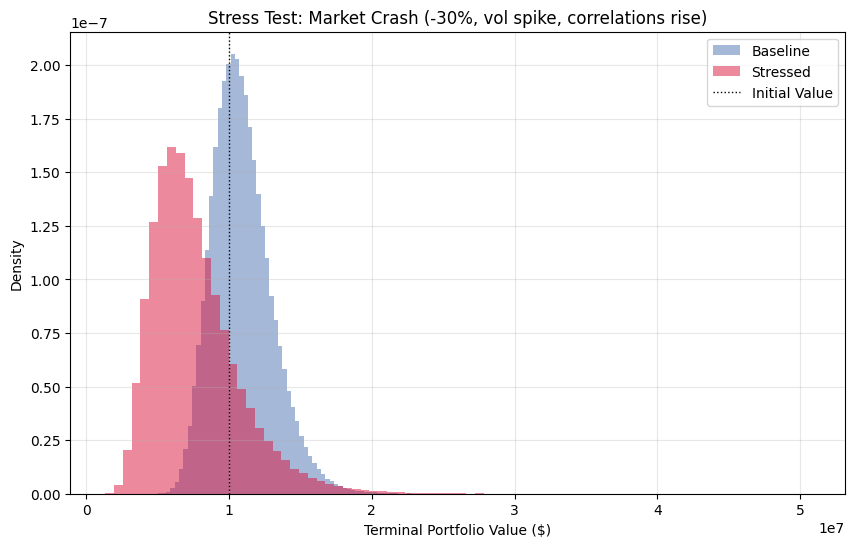

In [11]:
plot_stress_comparison(decline)
plt.show()

### Comparing all standard scenarios

In [12]:
results = {}
for key, scenario in STANDARD_SCENARIOS.items():
    results[key] = run_stress_test(portfolio, scenario, simulations=150_000, seed=SEED)

print(f"{'Scenario':<45}{'Value Change':>16}{'VaR Change':>16}")
print("-" * 77)
for key, r in results.items():
    print(f"{r.scenario.name:<45}{r.value_change:>16,.0f}{r.var_change:>16,.0f}")

Scenario                                         Value Change      VaR Change
-----------------------------------------------------------------------------
Market Decline (-15%)                              -1,637,402        -313,703
Market Crash (-30%, vol spike, correlations rise)      -3,274,224       1,067,011
Volatility Spike (+50%)                                   -99       1,246,868
Rate Hike (drift -200bp)                             -216,152         156,602
Correlations Rise (+0.30)                                  72         513,008


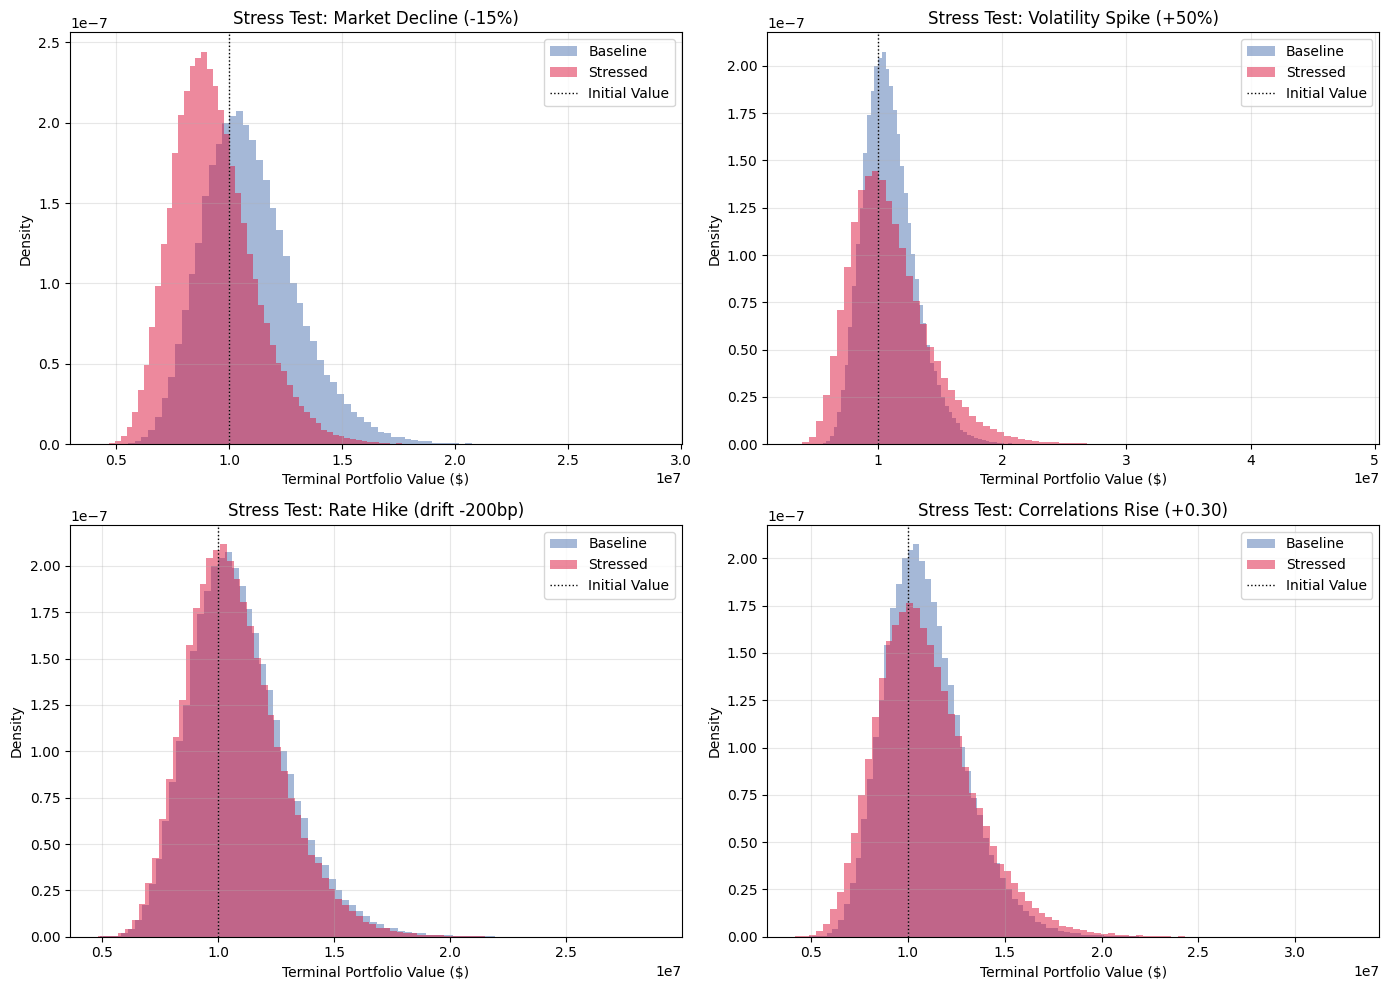

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, key in zip(axes.flat, ["market_decline_moderate", "volatility_spike", "rate_hike", "correlation_breakdown"]):
    plot_stress_comparison(results[key], ax=ax)
plt.tight_layout()
plt.show()

### A custom scenario

Scenarios aren't limited to the standard library — any combination of
shocks can be composed directly.

In [14]:
custom = Scenario(
    name="Stagflation (rates up, vol up, growth stocks hit hardest)",
    price_shock_pct=-0.12, volatility_multiplier=1.4, drift_shift=-0.015,
)
custom_result = run_stress_test(portfolio, custom, simulations=200_000, confidence_level=0.99, seed=SEED)
print(custom_result)

Stress Scenario: Stagflation (rates up, vol up, growth stocks hit hardest)
--------------------------------------------------------------------------
Baseline Expected Value:  $10,915,848.54
Stressed Expected Value:  $9,462,594.05
Value Change:             $-1,453,254.49 (-14.53%)

Baseline 99% VaR / ES:  $3,003,339.44 / $3,395,336.38
Stressed 99% VaR / ES:  $3,752,798.42 / $4,133,255.31
VaR Change:                $749,458.98


## 6. Key Findings

- **Correlation is recovered accurately at scale.** With 500k
  simulations the realized correlation matrix matches the target to
  within roughly ±0.01 — the Cholesky-induced correlation converges the
  same way simulated moments converged to theoretical ones in Week 1.
- **Historical and parametric VaR/ES diverge**, more so at higher
  confidence levels (99% vs. 95%), because portfolio P&L is a weighted
  sum of log-normal terms, not exactly Normal — the parametric method's
  Normality assumption is an approximation, most stressed exactly where
  tail risk matters most.
- **ES is always >= VaR** at the same confidence level in every result
  above, as it must be by construction (ES averages everything at or
  beyond the VaR threshold).
- **Volatility and correlation shocks increase VaR even with unchanged
  expected value** — risk and expected return are separable levers, and
  a stress test that only tracked expected P&L would miss this entirely.
- **Correctly modeling a price shock requires fixing share counts**, not
  dollar allocations, across the baseline/stressed comparison — the
  bug this notebook's `run_stress_test` avoids (see Section 5) is a
  realistic mistake that would otherwise silently produce a zero-impact
  "market decline."

## Roadmap (Not Yet Implemented)

- **Week 4 — FinTech Product:** interactive dashboard (FastAPI +
  Plotly/JS) exposing this and the Week 1/2 engines through an API,
  with live market-data integration (yfinance) for calibrating
  `AssetParameters` and `correlation_matrix` from historical returns
  rather than assumed inputs.
- **Path-dependent risk:** this module simulates only terminal (`T`)
  portfolio value; a full risk system would also track interim drawdown
  using Week 1's `mode="full"` path output.
- **Greeks-based risk (delta/vega) for portfolios holding options**,
  building on Week 2's `black_scholes.py` d1/d2 machinery.